# Tuning a multicell cavity: mid and end cells

In a multicell cavity the accelerating mode is the **&pi;-mode** — the highest
frequency of the fundamental passband, where the field flips sign from cell to
cell. Two jobs have to be done to place it on target with a **flat field**:

- The **interior (mid) cells** set the passband. Tuning the shared equator radius
  `Req` of the mid cells moves the whole passband, and with it the &pi;-mode.
- The **end cells** are perturbed by the beam pipes, which pull their frequency
  away from the interior. Left uncorrected the end cells are under-excited and the
  field is not flat. They are tuned **independently** — here through the end-cell
  half-length `L` — to restore flatness and pin the &pi;-mode exactly.

We build a 9-cell TESLA-like cavity with beam pipes and tune it in two stages.
See the [tuning guide](../../tuning).

In [1]:
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cavsim2d import EllipticalCavity
from cavsim2d.utils.style import apply_style, WARM

apply_style()

EIG = {'polarisation': 'monopole', 'n_modes': 12,
       'boundary_conditions': 'mm', 'mesh_config': {'h': 6, 'p': 2}}

def pi_mode(cav):
    """Solve and return (pi-mode frequency [MHz], field flatness [%])."""
    cav.eigenmode.run(EIG)
    q = cav.eigenmode.qois
    return q['freq [MHz]'], q['ff [%]']

def axis_field(cav):
    """On-axis |Ez| profile of the last-solved mode, peak-normalised."""
    df = pd.read_csv(cav.eigenmode.pol_folder(0) / 'Ez_0_abs.csv', sep='\t')
    z = df['z(0, 0)'].to_numpy()
    ez = df['|Ez(0, 0)|'].to_numpy()
    return z, ez / ez.max()

## 1. A detuned 9-cell cavity

All cells start identical with an oversized equator radius, and a beam pipe on
each end. `beampipe='both'` is what makes the end cells differ from the interior.

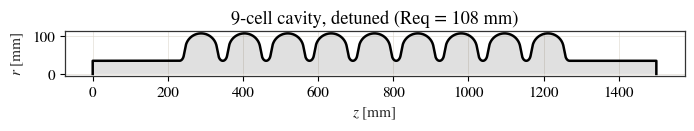

In [2]:
TESLA = [42, 42, 12, 19, 35, 57.7, 108.0]   # [A, B, a, b, Ri, L, Req], mm

def fresh(name):
    cav = EllipticalCavity(9, TESLA, list(TESLA), list(TESLA),
                           beampipe='both', name=name)
    cav.set_workspace(os.path.join(tempfile.mkdtemp(), name))
    return cav

ax = fresh('view').plot('geometry', show=False)
ax.set_title('9-cell cavity, detuned (Req = 108 mm)')
plt.show()

## 2. Stage one — tune the mid cells

Tuning only the mid-cell `Req` drops the &pi;-mode close to the target, but the
beam-pipe-loaded end cells are left untuned, so the field is far from flat.

In [3]:
cav_mid = fresh('mid_only')
cav_mid.tune.run({'freqs': 1300.0,
                  'cell_type': {'mid-cell': 'Req'},
                  'eigenmode_config': {'boundary_conditions': 'mm',
                                       'mesh_config': {'h': 6, 'p': 2}}})
f_mid, ff_mid = pi_mode(cav_mid.tuned)
print(f"mid cells only:  pi-mode = {f_mid:.3f} MHz,  field flatness = {ff_mid:.1f} %")

mid cells only:  pi-mode = 1299.426 MHz,  field flatness = 30.0 %


The on-axis field shows the two end cells sagging below the interior — the
signature of untuned, beam-pipe-loaded ends.

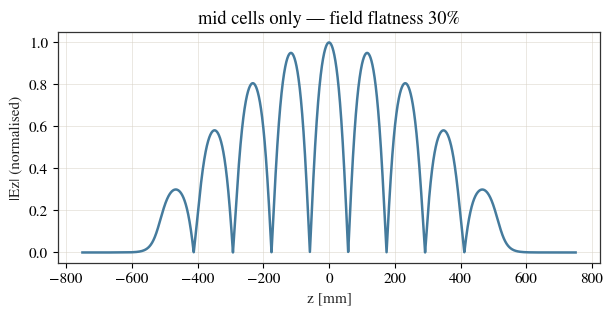

In [4]:
z, ez = axis_field(cav_mid.tuned)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(z * 1e3, ez, color=WARM[0])
ax.set_xlabel('z [mm]'); ax.set_ylabel('|Ez| (normalised)')
ax.set_title(f'mid cells only — field flatness {ff_mid:.0f}%')
plt.show()

## 3. Stage two — add the end cells

Now schedule **two** cell types in one call: the mid cells keep tuning `Req`, and
the end cells tune their half-length `L` independently. Because the stages run in
order, the end-cell tune sees the already-tuned interior and lengthens the end
cells just enough to compensate the beam-pipe loading.

In [5]:
cav = fresh('mid_and_end')
cav.tune.run({'freqs': 1300.0,
              'cell_type': {'mid-cell': 'Req', 'end-cell': 'L'},
              'eigenmode_config': {'boundary_conditions': 'mm',
                                   'mesh_config': {'h': 6, 'p': 2}}})
f_full, ff_full = pi_mode(cav.tuned)
print(f"mid + end cells: pi-mode = {f_full:.3f} MHz,  field flatness = {ff_full:.1f} %")

mid + end cells: pi-mode = 1300.040 MHz,  field flatness = 98.3 %


The field is now flat across all nine cells, and the &pi;-mode sits on 1300 MHz.

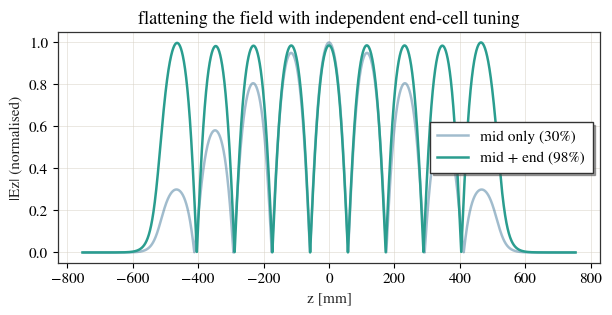

In [6]:
z2, ez2 = axis_field(cav.tuned)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(z * 1e3, ez, color=WARM[0], alpha=0.5, label=f'mid only ({ff_mid:.0f}%)')
ax.plot(z2 * 1e3, ez2, color=WARM[2], label=f'mid + end ({ff_full:.0f}%)')
ax.set_xlabel('z [mm]'); ax.set_ylabel('|Ez| (normalised)')
ax.set_title('flattening the field with independent end-cell tuning')
ax.legend()
plt.show()

## 4. The independently tuned cells

`cav.tune.qois` reports each cell type separately: the mid cells converged on an
equator radius, the end cells on a half-length. Both live on the single tuned
cavity, whose &pi;-mode is the target frequency.

In [7]:
mid = cav.tune.qois['mid-cell']
end = cav.tune.qois['end-cell']
print(f"mid cells:  Req = {mid['parameters']['Req_m']:.3f} mm   (tuned {mid['TUNED VARIABLES']})")
print(f"end cells:  L   = {end['parameters']['L_el']:.3f} mm   (tuned {end['TUNED VARIABLES']})")

mid cells:  Req = 103.365 mm   (tuned ['Req_m'])
end cells:  L   = 61.072 mm   (tuned ['L_el'])
